<a href="https://colab.research.google.com/github/aribarahmanii/Breasttumor/blob/main/dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("KGAT_8b7f8270011b57716959ecd71b74d6fd ")

KGAT_8b7f8270011b57716959ecd71b74d6fd ··········


In [2]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.8 MB/s eta 0:00:00


In [3]:
!kaggle datasets list -s breast-ultrasound

ref                                                              title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
aryashah2k/breast-ultrasound-images-dataset                      Breast Ultrasound Images Dataset                   204421470  2021-03-14 04:29:54.023000          73565        503                1  
vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer  Ultrasound Breast Images for Breast Cancer         591742845  2022-11-03 05:51:50.933000           4848         63             0.75  
orvile/bus-uc-breast-ultrasound                                  BUS_UC - Breast Ultrasound Dataset                 143163924  2025-07-06 00:01:54.773000           1117         36                1  
sabah

In [4]:
!mkdir -p /content/data

!kaggle datasets download \
    -d aryashah2k/breast-ultrasound-images-dataset \
    -p /content/data \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:02<00:00, 102MB/s] 



In [5]:
!find /content/data -maxdepth 2 -type d

/content/data
/content/data/Dataset_BUSI_with_GT
/content/data/Dataset_BUSI_with_GT/normal
/content/data/Dataset_BUSI_with_GT/benign
/content/data/Dataset_BUSI_with_GT/malignant


In [6]:
import os

root = '/content/data/Dataset_BUSI_with_GT'

for cls in ['normal', 'benign', 'malignant']:
    folder = os.path.join(root, cls)

    all_files = os.listdir(folder)

    images = [
        f for f in all_files
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        and '_mask' not in f.lower()
    ]

    masks = [
        f for f in all_files
        if '_mask' in f.lower()
    ]

    print(f"{cls:10s} → Images: {len(images):3d} | Masks: {len(masks):3d}")

normal     → Images: 133 | Masks: 133
benign     → Images: 437 | Masks: 454
malignant  → Images: 210 | Masks: 211


File: benign (103).png
Image size: (766, 585)
Image mode: RGB


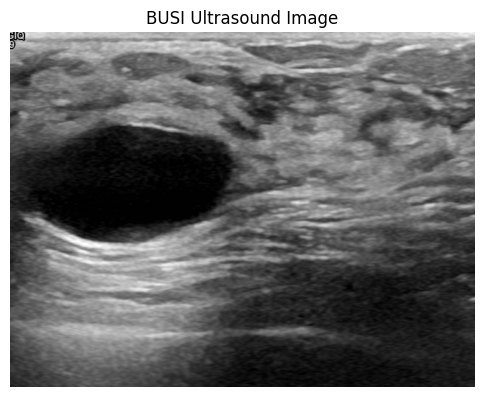

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image

folder = os.path.join(root, 'benign')

files = [
    f for f in os.listdir(folder)
    if f.lower().endswith('.png') and '_mask' not in f.lower()
]

image_file = files[0]
image_path = os.path.join(folder, image_file)

image = Image.open(image_path)

print("File:", image_file)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title("BUSI Ultrasound Image")
plt.show()

In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image

folder = os.path.join(root, 'benign')

image_file = 'benign (103).png'
image_path = os.path.join(folder, image_file)

# Find masks associated with this image
base_name = os.path.splitext(image_file)[0]

mask_files = [
    f for f in os.listdir(folder)
    if f.startswith(base_name + '_mask')
]

print("Image:", image_file)
print("Associated masks:", mask_files)

Image: benign (103).png
Associated masks: ['benign (103)_mask.png']


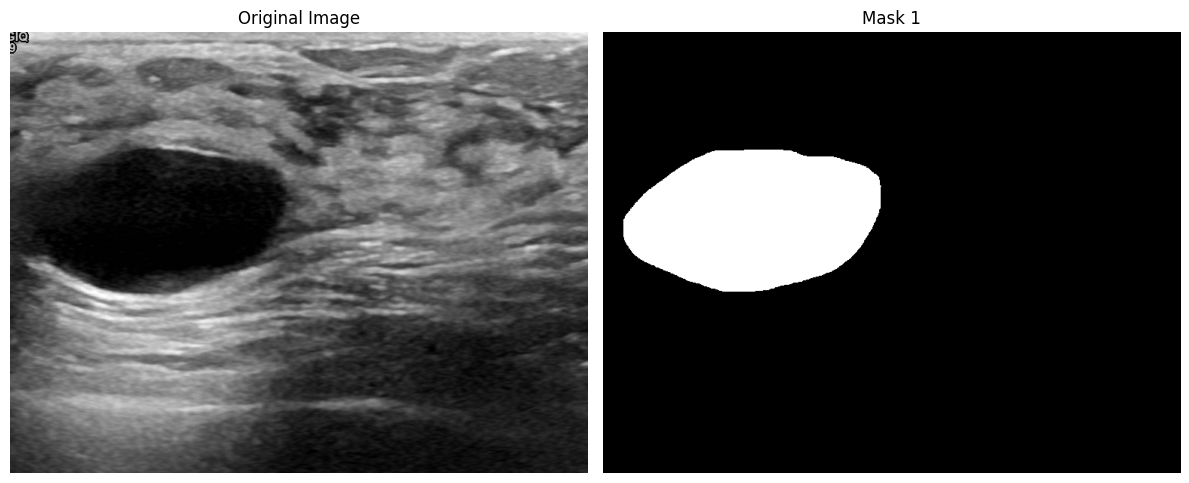

In [9]:
fig, axes = plt.subplots(1, len(mask_files) + 1, figsize=(12, 5))

# Original image
axes[0].imshow(Image.open(image_path))
axes[0].set_title("Original Image")
axes[0].axis('off')

# Masks
for i, mask_file in enumerate(mask_files):
    mask_path = os.path.join(folder, mask_file)
    axes[i + 1].imshow(Image.open(mask_path), cmap='gray')
    axes[i + 1].set_title(f"Mask {i+1}")
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
import os

root = '/content/data/Dataset_BUSI_with_GT'

for cls in ['normal', 'benign', 'malignant']:
    folder = os.path.join(root, cls)

    all_files = os.listdir(folder)

    images = [
        f for f in all_files
        if f.lower().endswith('.png') and '_mask' not in f.lower()
    ]

    masks = [
        f for f in all_files
        if '_mask' in f.lower()
    ]

    print(f'\n{cls.upper()}')
    print('Images:', len(images))
    print('Masks :', len(masks))


NORMAL
Images: 133
Masks : 133

BENIGN
Images: 437
Masks : 454

MALIGNANT
Images: 210
Masks : 211


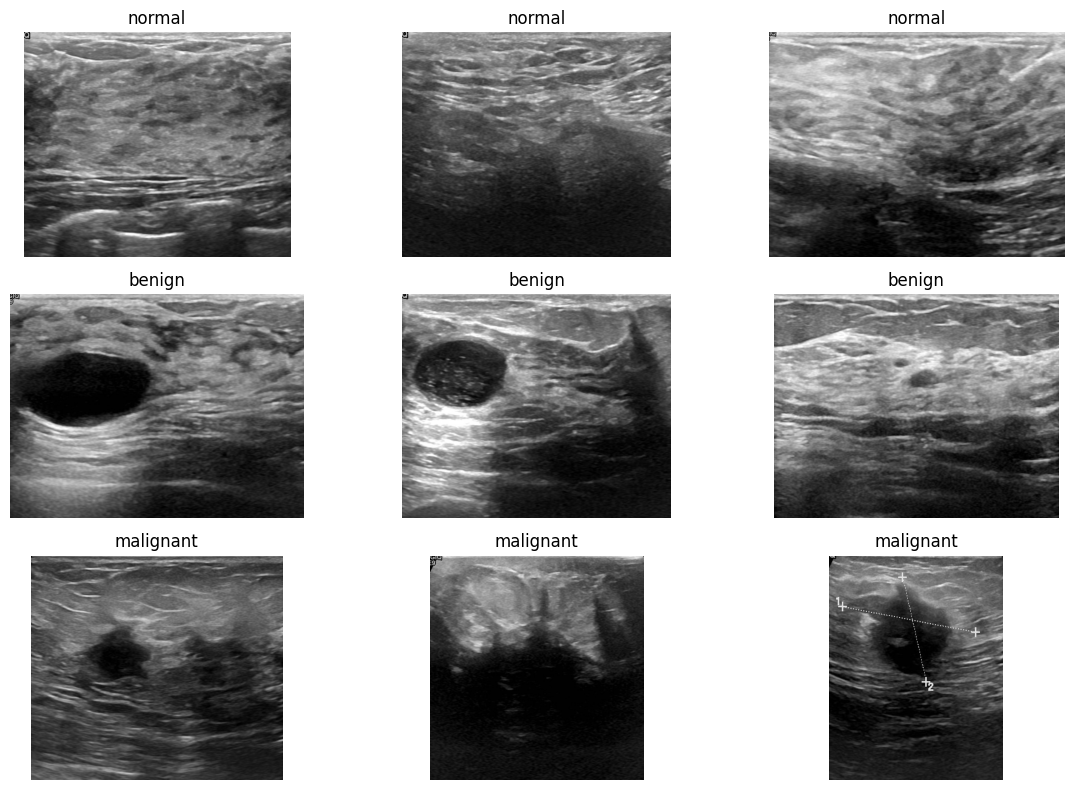

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
import os

classes = ['normal', 'benign', 'malignant']

plt.figure(figsize=(12, 8))

plot_number = 1

for cls in classes:
    folder = os.path.join(root, cls)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith('.png') and '_mask' not in f.lower()
    ]

    # Show first 3 images
    for image_file in images[:3]:
        image_path = os.path.join(folder, image_file)

        image = Image.open(image_path)

        plt.subplot(3, 3, plot_number)
        plt.imshow(image)
        plt.title(cls)
        plt.axis('off')

        plot_number += 1

plt.tight_layout()
plt.show()

In [12]:
import os
from collections import Counter

root = '/content/data/Dataset_BUSI_with_GT'

for cls in ['normal', 'benign', 'malignant']:
    folder = os.path.join(root, cls)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith('.png') and '_mask' not in f.lower()
    ]

    print(f"{cls}: {len(images)} images")

normal: 133 images
benign: 437 images
malignant: 210 images


In [13]:
import os
import hashlib
from collections import defaultdict

root = '/content/data/Dataset_BUSI_with_GT'

def file_hash(filepath):
    """Create an MD5 fingerprint of a file."""
    md5 = hashlib.md5()

    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)

    return md5.hexdigest()


# Store hashes
hashes = defaultdict(list)

for cls in ['normal', 'benign', 'malignant']:

    folder = os.path.join(root, cls)

    for filename in os.listdir(folder):

        # Only original images, NOT masks
        if filename.lower().endswith('.png') and '_mask' not in filename.lower():

            filepath = os.path.join(folder, filename)

            image_hash = file_hash(filepath)

            hashes[image_hash].append(filepath)


# Find duplicates
duplicates = {
    h: paths
    for h, paths in hashes.items()
    if len(paths) > 1
}


print("Unique image files:", len(hashes))
print("Duplicate groups:", len(duplicates))

duplicate_file_count = sum(len(paths) - 1 for paths in duplicates.values())

print("Extra duplicate files:", duplicate_file_count)

Unique image files: 779
Duplicate groups: 1
Extra duplicate files: 1


In [14]:
for image_hash, paths in duplicates.items():
    print("\nDuplicate group:")

    for path in paths:
        print(" ", path)


Duplicate group:
  /content/data/Dataset_BUSI_with_GT/benign/benign (433).png
  /content/data/Dataset_BUSI_with_GT/malignant/malignant (145).png


In [15]:
import os
from PIL import Image
import numpy as np

benign_img = os.path.join(
    root, 'benign', 'benign (433).png'
)

malignant_img = os.path.join(
    root, 'malignant', 'malignant (145).png'
)

# Find masks
benign_masks = [
    f for f in os.listdir(os.path.dirname(benign_img))
    if f.startswith('benign (433)_mask')
]

malignant_masks = [
    f for f in os.listdir(os.path.dirname(malignant_img))
    if f.startswith('malignant (145)_mask')
]

print("Benign masks:", benign_masks)
print("Malignant masks:", malignant_masks)

Benign masks: ['benign (433)_mask.png']
Malignant masks: ['malignant (145)_mask.png']


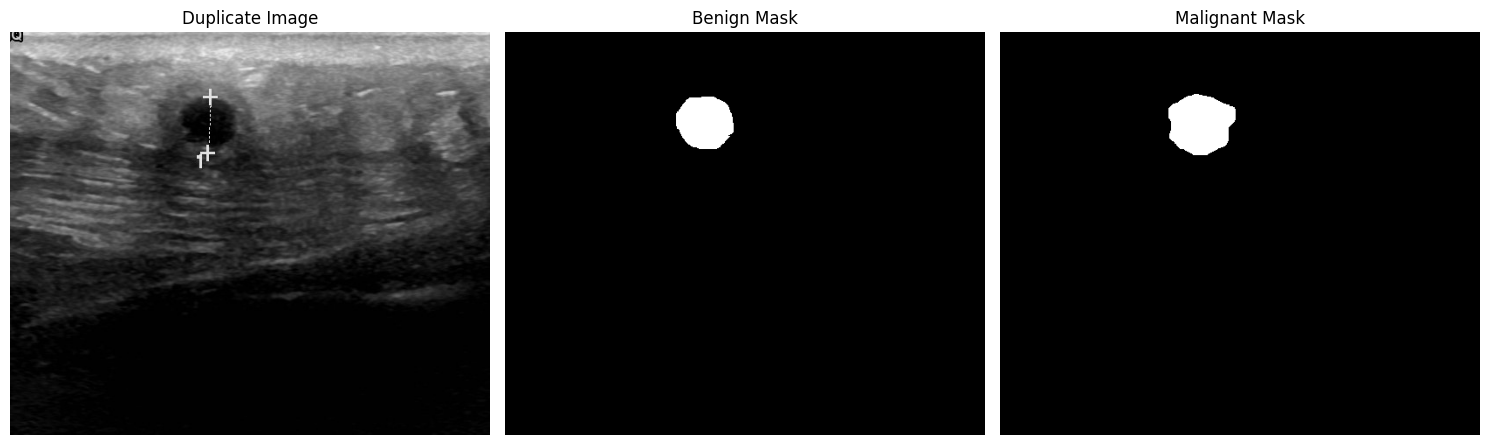

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
image = Image.open(benign_img)

axes[0].imshow(image)
axes[0].set_title("Duplicate Image")
axes[0].axis('off')

# Benign mask
if benign_masks:
    mask_b = Image.open(
        os.path.join(root, 'benign', benign_masks[0])
    )

    axes[1].imshow(mask_b, cmap='gray')
    axes[1].set_title("Benign Mask")
    axes[1].axis('off')

# Malignant mask
if malignant_masks:
    mask_m = Image.open(
        os.path.join(root, 'malignant', malignant_masks[0])
    )

    axes[2].imshow(mask_m, cmap='gray')
    axes[2].set_title("Malignant Mask")
    axes[2].axis('off')

plt.tight_layout()
plt.show()

In [17]:
print("Benign image:", Image.open(benign_img).size)
print("Malignant image:", Image.open(malignant_img).size)

Benign image: (550, 462)
Malignant image: (550, 462)


In [18]:
import os

benign_folder = os.path.join(root, 'benign')
malignant_folder = os.path.join(root, 'malignant')

benign_masks = [
    f for f in os.listdir(benign_folder)
    if f.startswith('benign (433)_mask')
]

malignant_masks = [
    f for f in os.listdir(malignant_folder)
    if f.startswith('malignant (145)_mask')
]

print("Benign masks:")
for f in benign_masks:
    print("  ", f)

print("\nMalignant masks:")
for f in malignant_masks:
    print("  ", f)

Benign masks:
   benign (433)_mask.png

Malignant masks:
   malignant (145)_mask.png


In [19]:
import hashlib

benign_mask_path = os.path.join(
    root, 'benign', 'benign (433)_mask.png'
)

malignant_mask_path = os.path.join(
    root, 'malignant', 'malignant (145)_mask.png'
)

def get_hash(filepath):
    md5 = hashlib.md5()

    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)

    return md5.hexdigest()


benign_mask_hash = get_hash(benign_mask_path)
malignant_mask_hash = get_hash(malignant_mask_path)

print("Benign mask hash:   ", benign_mask_hash)
print("Malignant mask hash:", malignant_mask_hash)

print("\nMasks identical:",
      benign_mask_hash == malignant_mask_hash)

Benign mask hash:    af20333bd8814c42f6b3c328743b2e10
Malignant mask hash: d39ccba8695a9dacc8ca84a0a4b40fe1

Masks identical: False


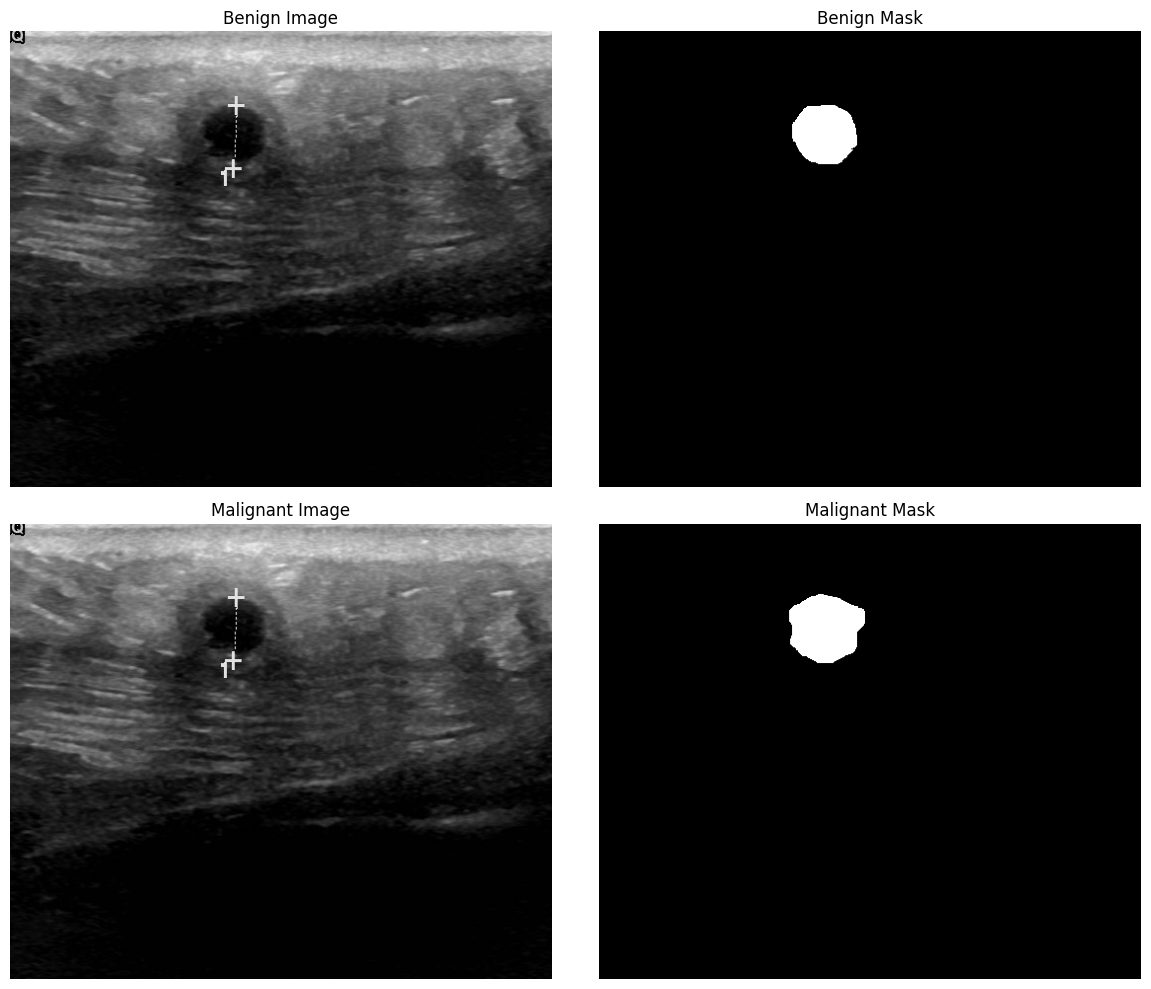

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

benign_img_path = os.path.join(
    root, 'benign', 'benign (433).png'
)

malignant_img_path = os.path.join(
    root, 'malignant', 'malignant (145).png'
)

benign_mask_path = os.path.join(
    root, 'benign', 'benign (433)_mask.png'
)

malignant_mask_path = os.path.join(
    root, 'malignant', 'malignant (145)_mask.png'
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Benign image
axes[0, 0].imshow(Image.open(benign_img_path))
axes[0, 0].set_title("Benign Image")
axes[0, 0].axis('off')

# Benign mask
axes[0, 1].imshow(Image.open(benign_mask_path), cmap='gray')
axes[0, 1].set_title("Benign Mask")
axes[0, 1].axis('off')

# Malignant image
axes[1, 0].imshow(Image.open(malignant_img_path))
axes[1, 0].set_title("Malignant Image")
axes[1, 0].axis('off')

# Malignant mask
axes[1, 1].imshow(Image.open(malignant_mask_path), cmap='gray')
axes[1, 1].set_title("Malignant Mask")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [21]:
!pip install -q ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.0 MB/s eta 0:00:00


In [22]:
import os
import imagehash
from PIL import Image
from collections import defaultdict

root = '/content/data/Dataset_BUSI_with_GT'

image_hashes = []

for cls in ['normal', 'benign', 'malignant']:

    folder = os.path.join(root, cls)

    for filename in os.listdir(folder):

        if filename.lower().endswith('.png') and '_mask' not in filename.lower():

            filepath = os.path.join(folder, filename)

            img = Image.open(filepath).convert('L')

            phash = imagehash.phash(img)

            image_hashes.append({
                'class': cls,
                'filename': filename,
                'path': filepath,
                'hash': phash
            })

print("Images processed:", len(image_hashes))

Images processed: 780


In [23]:
from itertools import combinations

# Maximum perceptual-hash distance to consider "near duplicate"
THRESHOLD = 5

near_duplicates = []

for a, b in combinations(image_hashes, 2):

    distance = a['hash'] - b['hash']

    if distance <= THRESHOLD:
        near_duplicates.append({
            'distance': distance,
            'class_a': a['class'],
            'file_a': a['filename'],
            'path_a': a['path'],
            'class_b': b['class'],
            'file_b': b['filename'],
            'path_b': b['path']
        })

print("Near-duplicate pairs:", len(near_duplicates))

# Show the first 20
for pair in near_duplicates[:20]:
    print(
        f"Distance: {pair['distance']} | "
        f"{pair['class_a']}/{pair['file_a']}  <-->  "
        f"{pair['class_b']}/{pair['file_b']}"
    )

Near-duplicate pairs: 186
Distance: 4 | normal/normal (127).png  <-->  normal/normal (32).png
Distance: 0 | normal/normal (98).png  <-->  normal/normal (97).png
Distance: 2 | normal/normal (19).png  <-->  normal/normal (131).png
Distance: 4 | normal/normal (57).png  <-->  normal/normal (67).png
Distance: 4 | normal/normal (57).png  <-->  normal/normal (68).png
Distance: 2 | normal/normal (43).png  <-->  normal/normal (38).png
Distance: 4 | normal/normal (43).png  <-->  normal/normal (53).png
Distance: 0 | normal/normal (43).png  <-->  normal/normal (50).png
Distance: 2 | normal/normal (52).png  <-->  normal/normal (54).png
Distance: 4 | normal/normal (52).png  <-->  normal/normal (51).png
Distance: 0 | normal/normal (31).png  <-->  normal/normal (121).png
Distance: 2 | normal/normal (29).png  <-->  normal/normal (123).png
Distance: 4 | normal/normal (67).png  <-->  normal/normal (55).png
Distance: 4 | normal/normal (67).png  <-->  normal/normal (68).png
Distance: 2 | normal/normal (119

In [24]:
from collections import Counter

distance_counts = Counter(
    pair['distance'] for pair in near_duplicates
)

print("Perceptual-hash distance distribution:")
for distance in sorted(distance_counts):
    print(f"Distance {distance}: {distance_counts[distance]} pairs")

Perceptual-hash distance distribution:
Distance 0: 44 pairs
Distance 2: 94 pairs
Distance 4: 48 pairs


In [25]:
print("Distance 0 candidates:\n")

for pair in near_duplicates:
    if pair['distance'] == 0:
        print(
            f"{pair['class_a']}/{pair['file_a']}  <-->  "
            f"{pair['class_b']}/{pair['file_b']}"
        )

Distance 0 candidates:

normal/normal (98).png  <-->  normal/normal (97).png
normal/normal (43).png  <-->  normal/normal (50).png
normal/normal (31).png  <-->  normal/normal (121).png
normal/normal (107).png  <-->  normal/normal (104).png
normal/normal (125).png  <-->  normal/normal (22).png
normal/normal (62).png  <-->  normal/normal (45).png
normal/normal (62).png  <-->  normal/normal (49).png
normal/normal (64).png  <-->  normal/normal (63).png
normal/normal (45).png  <-->  normal/normal (49).png
normal/normal (60).png  <-->  normal/normal (58).png
benign/benign (421).png  <-->  benign/benign (312).png
benign/benign (204).png  <-->  benign/benign (249).png
benign/benign (331).png  <-->  benign/benign (14).png
benign/benign (85).png  <-->  benign/benign (164).png
benign/benign (273).png  <-->  benign/benign (289).png
benign/benign (306).png  <-->  benign/benign (228).png
benign/benign (309).png  <-->  benign/benign (422).png
benign/benign (265).png  <-->  benign/benign (216).png
beni

In [26]:
print("CROSS-CLASS DISTANCE-0 CANDIDATES")
print("=" * 70)

for pair in near_duplicates:

    if pair['distance'] == 0 and pair['class_a'] != pair['class_b']:

        print(
            f"{pair['class_a']:10s} {pair['file_a']:25s}"
            f" <--> "
            f"{pair['class_b']:10s} {pair['file_b']}"
        )


CROSS-CLASS DISTANCE-0 CANDIDATES
benign     benign (399).png          <--> malignant  malignant (93).png
benign     benign (433).png          <--> malignant  malignant (145).png
benign     benign (42).png           <--> malignant  malignant (51).png


In [27]:
from PIL import Image
import numpy as np
import os

cross_class_pairs = [
    ('benign', 'benign (399).png', 'malignant', 'malignant (93).png'),
    ('benign', 'benign (433).png', 'malignant', 'malignant (145).png'),
    ('benign', 'benign (42).png', 'malignant', 'malignant (51).png')
]

for cls1, file1, cls2, file2 in cross_class_pairs:

    path1 = os.path.join(root, cls1, file1)
    path2 = os.path.join(root, cls2, file2)

    img1 = np.array(Image.open(path1))
    img2 = np.array(Image.open(path2))

    print("\n" + "=" * 70)
    print(f"{cls1}/{file1}")
    print(f"{cls2}/{file2}")

    print("Shape 1:", img1.shape)
    print("Shape 2:", img2.shape)

    if img1.shape == img2.shape:
        identical = np.array_equal(img1, img2)

        difference_pixels = np.sum(np.any(img1 != img2, axis=-1)) \
            if img1.ndim == 3 else np.sum(img1 != img2)

        total_pixels = img1.shape[0] * img1.shape[1]

        difference_percentage = (
            difference_pixels / total_pixels
        ) * 100

        print("Pixel-identical:", identical)
        print(f"Different pixels: {difference_pixels:,}")
        print(f"Difference: {difference_percentage:.4f}%")

    else:
        print("Pixel-identical: False")
        print("Images have different shapes.")


benign/benign (399).png
malignant/malignant (93).png
Shape 1: (468, 555, 3)
Shape 2: (470, 554, 3)
Pixel-identical: False
Images have different shapes.

benign/benign (433).png
malignant/malignant (145).png
Shape 1: (462, 550, 3)
Shape 2: (462, 550, 3)
Pixel-identical: True
Different pixels: 0
Difference: 0.0000%

benign/benign (42).png
malignant/malignant (51).png
Shape 1: (437, 581, 3)
Shape 2: (437, 588, 3)
Pixel-identical: False
Images have different shapes.


In [28]:
import numpy as np
from PIL import Image

benign_mask = np.array(
    Image.open(
        os.path.join(root, 'benign', 'benign (433)_mask.png')
    ).convert('L')
)

malignant_mask = np.array(
    Image.open(
        os.path.join(root, 'malignant', 'malignant (145)_mask.png')
    ).convert('L')
)

print("Benign mask shape:", benign_mask.shape)
print("Malignant mask shape:", malignant_mask.shape)

# Convert masks to binary
benign_binary = benign_mask > 0
malignant_binary = malignant_mask > 0

print("\nBenign mask pixels:", np.sum(benign_binary))
print("Malignant mask pixels:", np.sum(malignant_binary))

Benign mask shape: (462, 550)
Malignant mask shape: (462, 550)

Benign mask pixels: 3186
Malignant mask pixels: 4112


In [29]:
intersection = np.logical_and(
    benign_binary,
    malignant_binary
)

union = np.logical_or(
    benign_binary,
    malignant_binary
)

intersection_pixels = np.sum(intersection)
union_pixels = np.sum(union)

iou = intersection_pixels / union_pixels

print("Mask intersection:", intersection_pixels)
print("Mask union:", union_pixels)
print(f"Mask IoU: {iou:.4f}")

Mask intersection: 3186
Mask union: 4112
Mask IoU: 0.7748


In [30]:
import numpy as np
from PIL import Image
import os

def image_similarity(path1, path2):
    img1 = np.array(Image.open(path1).convert('L'))
    img2 = np.array(Image.open(path2).convert('L'))

    if img1.shape != img2.shape:
        return None

    # Percentage of pixels that are exactly equal
    equal_pixels = np.sum(img1 == img2)
    total_pixels = img1.size

    return (equal_pixels / total_pixels) * 100


# Check all pHash distance 0 candidates
verified_pairs = []

for pair in near_duplicates:

    if pair['distance'] != 0:
        continue

    similarity = image_similarity(
        pair['path_a'],
        pair['path_b']
    )

    verified_pairs.append({
        'distance': pair['distance'],
        'class_a': pair['class_a'],
        'file_a': pair['file_a'],
        'class_b': pair['class_b'],
        'file_b': pair['file_b'],
        'similarity': similarity
    })


print("Distance-0 candidates:", len(verified_pairs))
print()

for pair in verified_pairs:
    if pair['similarity'] is not None and pair['similarity'] == 100:
        print(
            f"EXACT: "
            f"{pair['class_a']}/{pair['file_a']}  <-->  "
            f"{pair['class_b']}/{pair['file_b']}"
        )

Distance-0 candidates: 44

EXACT: benign/benign (433).png  <-->  malignant/malignant (145).png


In [31]:
import os
import hashlib
import random
import csv
from collections import defaultdict
from itertools import combinations

from PIL import Image
import imagehash  # !pip install -q ImageHash

random.seed(42)

ROOT = '/content/data/Dataset_BUSI_with_GT'
CLASSES = ['benign', 'malignant']  # normal excluded — no lesion mask
NEAR_DUP_THRESHOLD = 5  # perceptual-hash distance; matches your exploratory pass
OUTPUT_DIR = '/content/data/splits'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [32]:
def collect_images(root, classes):
    records = []
    for cls in classes:
        folder = os.path.join(root, cls)
        all_files = os.listdir(folder)
        images = [f for f in all_files
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))
                  and '_mask' not in f.lower()]
        for image_file in images:
            base_name = os.path.splitext(image_file)[0]
            masks = [f for f in all_files if f.startswith(base_name + '_mask')]
            records.append({
                'class': cls,
                'filename': image_file,
                'image_path': os.path.join(folder, image_file),
                'mask_paths': [os.path.join(folder, m) for m in masks],
            })
    return records


def md5_hash(filepath):
    md5 = hashlib.md5()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)
    return md5.hexdigest()

In [33]:
def collect_images(root, classes):
    records = []
    for cls in classes:
        folder = os.path.join(root, cls)
        all_files = os.listdir(folder)
        images = [f for f in all_files
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))
                  and '_mask' not in f.lower()]
        for image_file in images:
            base_name = os.path.splitext(image_file)[0]
            masks = [f for f in all_files if f.startswith(base_name + '_mask')]
            records.append({
                'class': cls,
                'filename': image_file,
                'image_path': os.path.join(folder, image_file),
                'mask_paths': [os.path.join(folder, m) for m in masks],
            })
    return records


def md5_hash(filepath):
    md5 = hashlib.md5()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)
    return md5.hexdigest()


def phash(filepath):
    return imagehash.phash(Image.open(filepath).convert('L'))

In [34]:
def find_exact_duplicate_groups(records):
    groups = defaultdict(list)
    for r in records:
        groups[md5_hash(r['image_path'])].append(r)
    return [g for g in groups.values() if len(g) > 1]

In [35]:
def find_near_duplicate_pairs(records, threshold):
    hashes = [(r, phash(r['image_path'])) for r in records]
    pairs = []
    for (r_a, h_a), (r_b, h_b) in combinations(hashes, 2):
        distance = h_a - h_b
        if distance <= threshold:
            pairs.append((r_a, r_b, distance))
    return pairs


class UnionFind:
    def __init__(self, items):
        self.parent = {id(item): item for item in items}
        self.rank = {id(item): 0 for item in items}

    def find(self, item):
        pid = id(item)
        while self.parent[pid] is not item:
            item = self.parent[pid]
            pid = id(item)
        return item

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra is not rb:
            self.parent[id(ra)] = rb


def group_near_duplicates(records, pairs):
    uf = UnionFind(records)
    for r_a, r_b, _dist in pairs:
        uf.union(r_a, r_b)
    groups = defaultdict(list)
    for r in records:
        root_item = uf.find(r)
        groups[id(root_item)].append(r)
    return [g for g in groups.values() if len(g) > 1]

In [36]:
print("Collecting image records...")
records = collect_images(ROOT, CLASSES)
print(f"Total benign+malignant images: {len(records)}")

print("\nFinding exact (MD5) duplicates...")
exact_groups = find_exact_duplicate_groups(records)
print(f"Exact duplicate groups: {len(exact_groups)}")

print("\nComputing perceptual hashes and finding near-duplicate pairs "
      f"(threshold={NEAR_DUP_THRESHOLD})...")
near_pairs = find_near_duplicate_pairs(records, NEAR_DUP_THRESHOLD)
near_groups = group_near_duplicates(records, near_pairs)
print(f"Near-duplicate groups (incl. exact matches): {len(near_groups)}")

# Split near-duplicate groups into same-class (safe to dedupe) vs cross-class (exclude)
same_class_groups = []
cross_class_groups = []
for g in near_groups:
    classes_in_group = set(r['class'] for r in g)
    if len(classes_in_group) > 1:
        cross_class_groups.append(g)
    else:
        same_class_groups.append(g)

print(f"\nSame-class duplicate/near-duplicate groups: {len(same_class_groups)} "
      f"(will keep 1 representative each)")
print(f"CROSS-CLASS conflicting groups: {len(cross_class_groups)} "
      f"(will EXCLUDE all images in these groups)")

if cross_class_groups:
    print("\nCross-class conflicts (excluded — contradictory ground truth):")
    for g in cross_class_groups:
        desc = ", ".join(f"{r['class']}/{r['filename']}" for r in g)
        print(f"  {desc}")

Total benign+malignant images: 647

Finding exact (MD5) duplicates...
Exact duplicate groups: 1

Computing perceptual hashes and finding near-duplicate pairs (threshold=5)...
Near-duplicate groups (incl. exact matches): 98

Same-class duplicate/near-duplicate groups: 92 (will keep 1 representative each)
CROSS-CLASS conflicting groups: 6 (will EXCLUDE all images in these groups)

Cross-class conflicts (excluded — contradictory ground truth):
  benign/benign (333).png, malignant/malignant (77).png
  benign/benign (85).png, benign/benign (164).png, malignant/malignant (52).png
  benign/benign (131).png, benign/benign (42).png, malignant/malignant (51).png
  benign/benign (399).png, malignant/malignant (93).png
  benign/benign (433).png, malignant/malignant (145).png
  benign/benign (406).png, malignant/malignant (94).png


In [37]:
excluded_paths = set()
for g in cross_class_groups:
    for r in g:
        excluded_paths.add(r['image_path'])

kept_records = []
seen_paths = set()
for g in same_class_groups:
    representative = g[0]  # keep first; order is stable from os.listdir + collect order
    kept_records.append(representative)
    seen_paths.add(representative['image_path'])
    for r in g[1:]:
        seen_paths.add(r['image_path'])  # mark as consumed, not kept

for r in records:
    if r['image_path'] in excluded_paths:
        continue
    if r['image_path'] in seen_paths:
        continue  # already handled above (either kept or dropped as a dup)
    kept_records.append(r)

print(f"\nFinal deduplicated dataset: {len(kept_records)} images "
      f"(started at {len(records)}, "
      f"removed {len(records) - len(kept_records)})")

for cls in CLASSES:
    n = sum(1 for r in kept_records if r['class'] == cls)
    print(f"  {cls}: {n} images")



Final deduplicated dataset: 527 images (started at 647, removed 120)
  benign: 334 images
  malignant: 193 images


In [38]:
def stratified_split(records, classes, ratios=(0.70, 0.15, 0.15)):
    train, val, test = [], [], []
    for cls in classes:
        cls_records = [r for r in records if r['class'] == cls]
        random.shuffle(cls_records)
        n = len(cls_records)
        n_train = int(n * ratios[0])
        n_val = int(n * ratios[1])
        train.extend(cls_records[:n_train])
        val.extend(cls_records[n_train:n_train + n_val])
        test.extend(cls_records[n_train + n_val:])
    random.shuffle(train)
    random.shuffle(val)
    random.shuffle(test)
    return train, val, test


train, val, test = stratified_split(kept_records, CLASSES)
print(f"\nSplit sizes — train: {len(train)}, val: {len(val)}, test: {len(test)}")
for split_name, split_data in [('train', train), ('val', val), ('test', test)]:
    for cls in CLASSES:
        n = sum(1 for r in split_data if r['class'] == cls)
        print(f"  {split_name} / {cls}: {n}")


Split sizes — train: 368, val: 78, test: 81
  train / benign: 233
  train / malignant: 135
  val / benign: 50
  val / malignant: 28
  test / benign: 51
  test / malignant: 30


In [39]:
def save_split_csv(path, records):
    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['class', 'image_path', 'mask_paths'])
        for r in records:
            writer.writerow([r['class'], r['image_path'], '|'.join(r['mask_paths'])])

save_split_csv(os.path.join(OUTPUT_DIR, 'train.csv'), train)
save_split_csv(os.path.join(OUTPUT_DIR, 'val.csv'), val)
save_split_csv(os.path.join(OUTPUT_DIR, 'test.csv'), test)

print(f"\nSplits saved to {OUTPUT_DIR}/{{train,val,test}}.csv")
print("Reuse these exact CSVs for Attention U-Net, D-SAS, and CA-BSNet — "
      "never re-split, or the three tiers won't be comparable.")


Splits saved to /content/data/splits/{train,val,test}.csv
Reuse these exact CSVs for Attention U-Net, D-SAS, and CA-BSNet — never re-split, or the three tiers won't be comparable.


In [40]:
print("\n" + "=" * 70)
print("METHODOLOGY SECTION SUMMARY (copy into your write-up)")
print("=" * 70)
print(f"Starting BUSI benign+malignant images: {len(records)}")
print(f"Exact (MD5) duplicate groups found: {len(exact_groups)}")
print(f"Same-class near-duplicate groups collapsed to 1 representative: "
      f"{len(same_class_groups)}")
print(f"Cross-class label-conflicting groups excluded entirely: "
      f"{len(cross_class_groups)} groups, {sum(len(g) for g in cross_class_groups)} images")
print(f"Final cleaned dataset: {len(kept_records)} images")
print(f"Split: train={len(train)}, val={len(val)}, test={len(test)} (70/15/15, stratified)")


METHODOLOGY SECTION SUMMARY (copy into your write-up)
Starting BUSI benign+malignant images: 647
Exact (MD5) duplicate groups found: 1
Same-class near-duplicate groups collapsed to 1 representative: 92
Cross-class label-conflicting groups excluded entirely: 6 groups, 14 images
Final cleaned dataset: 527 images
Split: train=368, val=78, test=81 (70/15/15, stratified)
